In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from clean import clean_data

pd.set_option("display.max_columns", 50)


In [4]:
import os
FIGDIR = "../figs"
os.makedirs(FIGDIR, exist_ok=True)

In [5]:
#Load raw data and run it through the cleaning pipeline
raw = pd.read_csv("../data/TBI PUD 10-08-2013.csv") #relative path!
cleaned = clean_data(raw)
#alias used below wherever a plot needs the raw, uncleaned values
df = raw.copy()


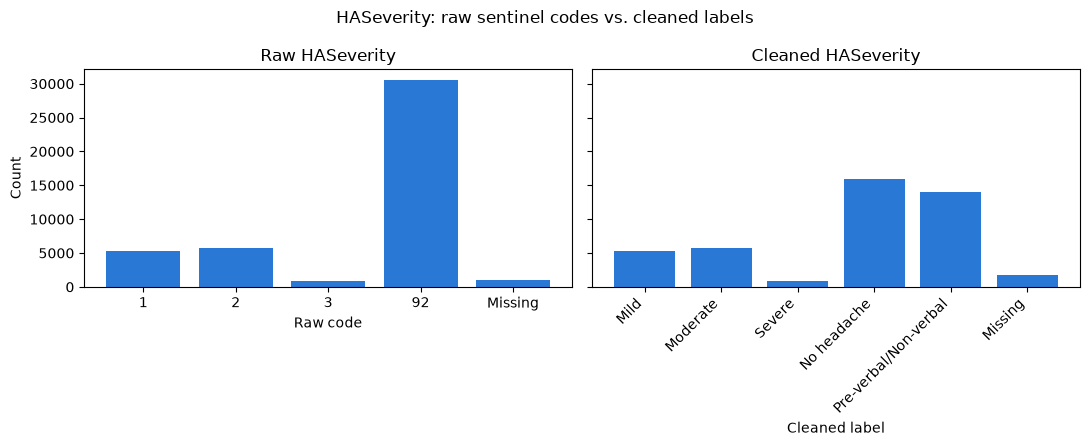

In [6]:
#Figure 1: HASeverity raw sentinel codes vs. cleaned labels
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

raw_order = [1, 2, 3, 92, "Missing"]
raw_counts = df["HASeverity"].fillna("Missing").value_counts().reindex(raw_order)

axes[0].bar([str(x) for x in raw_order], raw_counts, color="#2a78d6")
axes[0].set_title("Raw HASeverity")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Raw code")

cleaned_order = ["Mild", "Moderate", "Severe", "No headache", "Pre-verbal/Non-verbal", "Missing"]
cleaned_counts = cleaned["HASeverity"].fillna("Missing").value_counts().reindex(cleaned_order)

axes[1].bar(cleaned_order, cleaned_counts, color="#2a78d6")
axes[1].set_title("Cleaned HASeverity")
axes[1].set_xlabel("Cleaned label")
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

fig.suptitle("HASeverity: raw sentinel codes vs. cleaned labels")
plt.tight_layout()
plt.savefig(FIGDIR + "/haseverity_raw_vs_cleaned.png", dpi=150)
plt.show()

In [7]:
#Numeric check for Figure 1: raw '92' splits cleanly into the two cleaned labels
print("Raw HASeverity counts:")
print(raw_counts)
print()
print("Cleaned HASeverity counts:")
print(cleaned_counts)
print()

raw_92 = raw_counts[92]
cleaned_no_headache_and_preverbal = cleaned_counts["No headache"] + cleaned_counts["Pre-verbal/Non-verbal"]
print(f"Raw '92' count: {raw_92}")
print(f"Cleaned 'No headache' + 'Pre-verbal/Non-verbal': {cleaned_no_headache_and_preverbal}")
print(f"Difference (should roughly equal HA_verb-missing rows folded into cleaned 'Missing'): {raw_92 - cleaned_no_headache_and_preverbal}")

Raw HASeverity counts:
HASeverity
1           5266
2           5671
3            825
92         30593
Missing     1044
Name: count, dtype: int64

Cleaned HASeverity counts:
HASeverity
Mild                      5266
Moderate                  5671
Severe                     825
No headache              15881
Pre-verbal/Non-verbal    14060
Missing                   1696
Name: count, dtype: int64

Raw '92' count: 30593
Cleaned 'No headache' + 'Pre-verbal/Non-verbal': 29941
Difference (should roughly equal HA_verb-missing rows folded into cleaned 'Missing'): 652


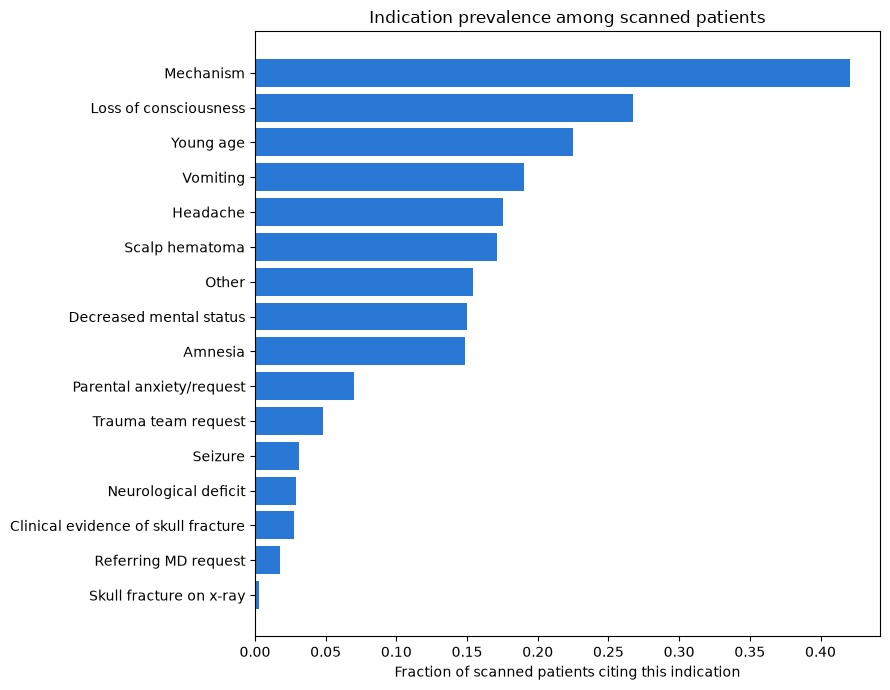

In [10]:
#Exploration: how common is each indication among scanned patients
import pandas as pd
import matplotlib.pyplot as plt

indication_cols = [
    "IndAge", "IndAmnesia", "IndAMS", "IndClinSFx", "IndHA", "IndHema",
    "IndLOC", "IndMech", "IndNeuroD", "IndRqstMD", "IndRqstParent",
    "IndRqstTrauma", "IndSeiz", "IndVomit", "IndXraySFx", "IndOth",
]

display_names = {
    "IndAge": "Young age", "IndAmnesia": "Amnesia", "IndAMS": "Decreased mental status",
    "IndClinSFx": "Clinical evidence of skull fracture", "IndHA": "Headache",
    "IndHema": "Scalp hematoma", "IndLOC": "Loss of consciousness", "IndMech": "Mechanism",
    "IndNeuroD": "Neurological deficit", "IndRqstMD": "Referring MD request",
    "IndRqstParent": "Parental anxiety/request", "IndRqstTrauma": "Trauma team request",
    "IndSeiz": "Seizure", "IndVomit": "Vomiting", "IndXraySFx": "Skull fracture on x-ray",
    "IndOth": "Other",
}

scanned = cleaned[cleaned["CTDone"] == "Yes"].copy()

prevalence = pd.Series(
    {display_names[col]: (scanned[col] == "Yes").mean() for col in indication_cols}
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(prevalence.index, prevalence.values, color="#2a78d6")
ax.set_xlabel("Fraction of scanned patients citing this indication")
ax.set_title("Indication prevalence among scanned patients")
plt.tight_layout()
plt.savefig(FIGDIR + "/indication_prevalence.png", dpi=150)
plt.show()

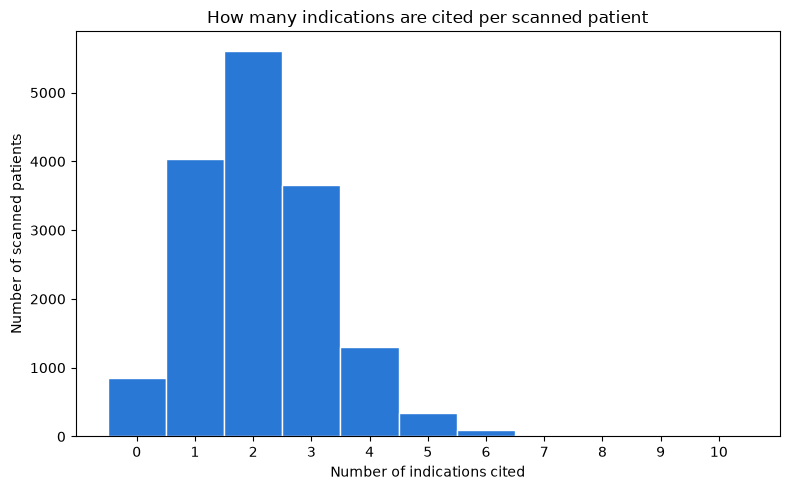

In [11]:
#Exploration: how many indications are cited per scanned patient
import matplotlib.pyplot as plt

n_indications = (scanned[indication_cols] == "Yes").sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(n_indications, bins=range(0, n_indications.max() + 2), align="left",
        color="#2a78d6", edgecolor="white")
ax.set_xlabel("Number of indications cited")
ax.set_ylabel("Number of scanned patients")
ax.set_title("How many indications are cited per scanned patient")
ax.set_xticks(range(0, n_indications.max() + 1))
plt.tight_layout()
plt.savefig(FIGDIR + "/indications_per_patient.png", dpi=150)
plt.show()

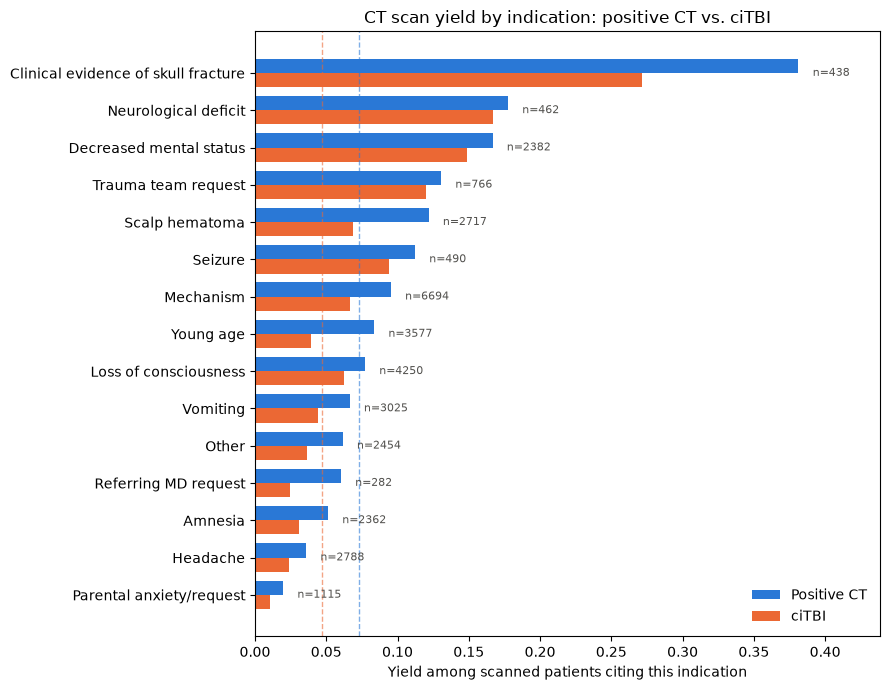

In [12]:
#Finding: CT scan yield by physician-stated indication (positive CT vs. ciTBI)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

indication_cols = [
    "IndAge", "IndAmnesia", "IndAMS", "IndClinSFx", "IndHA", "IndHema",
    "IndLOC", "IndMech", "IndNeuroD", "IndRqstMD", "IndRqstParent",
    "IndRqstTrauma", "IndSeiz", "IndVomit", "IndXraySFx", "IndOth",
]

display_names = {
    "IndAge": "Young age", "IndAmnesia": "Amnesia", "IndAMS": "Decreased mental status",
    "IndClinSFx": "Clinical evidence of skull fracture", "IndHA": "Headache",
    "IndHema": "Scalp hematoma", "IndLOC": "Loss of consciousness", "IndMech": "Mechanism",
    "IndNeuroD": "Neurological deficit", "IndRqstMD": "Referring MD request",
    "IndRqstParent": "Parental anxiety/request", "IndRqstTrauma": "Trauma team request",
    "IndSeiz": "Seizure", "IndVomit": "Vomiting", "IndXraySFx": "Skull fracture on x-ray",
    "IndOth": "Other",
}

scanned = cleaned[cleaned["CTDone"] == "Yes"].copy()
overall_posct_yield = (scanned["PosCT"] == "Yes").mean()
overall_citbi_yield = (scanned["PosIntFinal"] == "Yes").mean()

rows = []
for col in indication_cols:
    sub = scanned[scanned[col] == "Yes"]
    n = len(sub)
    posct_yield = (sub["PosCT"] == "Yes").mean() if n > 0 else np.nan
    citbi_yield = (sub["PosIntFinal"] == "Yes").mean() if n > 0 else np.nan
    rows.append({"indication": col, "label": display_names[col], "n": n,
                 "posct_yield": posct_yield, "citbi_yield": citbi_yield})

yield_df = pd.DataFrame(rows)
yield_df = yield_df[yield_df["indication"] != "IndXraySFx"]
yield_df = yield_df.sort_values("posct_yield", ascending=True).reset_index(drop=True)

y = np.arange(len(yield_df))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(y + bar_height / 2, yield_df["posct_yield"], height=bar_height, color="#2a78d6", label="Positive CT")
ax.barh(y - bar_height / 2, yield_df["citbi_yield"], height=bar_height, color="#eb6834", label="ciTBI")

ax.axvline(overall_posct_yield, color="#2a78d6", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(overall_citbi_yield, color="#eb6834", linestyle="--", linewidth=1, alpha=0.6)

for yi, n in zip(y, yield_df["n"]):
    ax.text(max(yield_df.loc[yi, "posct_yield"], yield_df.loc[yi, "citbi_yield"]) + 0.01,
            yi, f"n={n}", va="center", fontsize=8, color="#52514e")

ax.set_yticks(y)
ax.set_yticklabels(yield_df["label"])
ax.set_xlabel("Yield among scanned patients citing this indication")
ax.set_title("CT scan yield by indication: positive CT vs. ciTBI")
ax.legend(loc="lower right", frameon=False)
max_val = yield_df[["posct_yield", "citbi_yield"]].max().max()
ax.set_xlim(0, max_val * 1.15)
plt.tight_layout()
plt.savefig(FIGDIR + "/indication_yield.png", dpi=150)
plt.show()

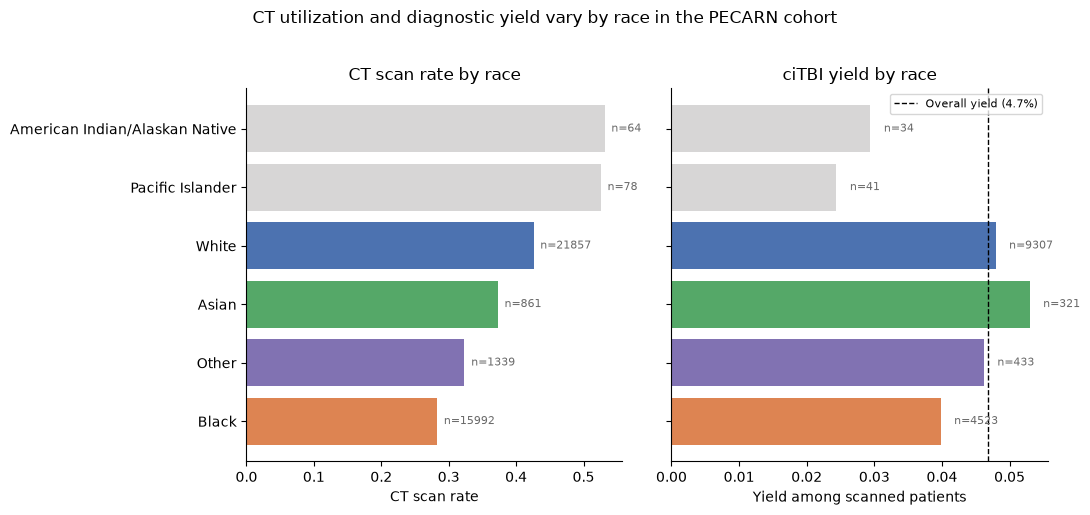

In [13]:
#Finding: CT utilization and diagnostic yield by race
import matplotlib.pyplot as plt
import numpy as np

ct_rate = (cleaned["CTDone"] == "Yes").groupby(cleaned["Race"]).agg(["mean", "count"])
ct_patients = cleaned[cleaned["CTDone"] == "Yes"]
yield_tab = (ct_patients["PosIntFinal"] == "Yes").groupby(ct_patients["Race"]).agg(["mean", "count"])

order = ct_rate.sort_values("mean").index.tolist()
LOW_N = {"American Indian/Alaskan Native", "Pacific Islander"}  # n<50, flag as unreliable

colors = {
    "White": "#4C72B0", "Black": "#DD8452", "Asian": "#55A868",
    "Other": "#8172B2", "American Indian/Alaskan Native": "#B0AFAF",
    "Pacific Islander": "#B0AFAF",
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
y_pos = np.arange(len(order))

# Panel 1: CT scan rate
ax = axes[0]
bars = ax.barh(y_pos, [ct_rate.loc[r, "mean"] for r in order],
                color=[colors[r] for r in order])
for b, r in zip(bars, order):
    b.set_alpha(0.5 if r in LOW_N else 1.0)
ax.set_yticks(y_pos); ax.set_yticklabels(order)
ax.set_xlabel("CT scan rate"); ax.set_title("CT scan rate by race")
for i, r in enumerate(order):
    ax.text(ct_rate.loc[r, "mean"] + 0.01, i, f"n={int(ct_rate.loc[r,'count'])}",
             va="center", fontsize=8, color="dimgray")

# Panel 2: Yield among CT patients
ax = axes[1]
bars = ax.barh(y_pos, [yield_tab.loc[r, "mean"] for r in order],
                color=[colors[r] for r in order])
for b, r in zip(bars, order):
    b.set_alpha(0.5 if r in LOW_N else 1.0)
overall_yield = (ct_patients["PosIntFinal"] == "Yes").mean()
ax.axvline(overall_yield, color="black", linestyle="--", linewidth=1,
            label=f"Overall yield ({overall_yield:.1%})")
ax.set_xlabel("Yield among scanned patients"); ax.set_title("ciTBI yield by race")
for i, r in enumerate(order):
    ax.text(yield_tab.loc[r, "mean"] + 0.002, i, f"n={int(yield_tab.loc[r,'count'])}",
             va="center", fontsize=8, color="dimgray")
ax.legend(fontsize=8, loc="upper right")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("CT utilization and diagnostic yield vary by race in the PECARN cohort", y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR + "/race_ct_yield.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
#Stability check: does mechanism-severity mix differ by race?
#Part 1: does mechanism severity distribution even differ by race?
print(pd.crosstab(cleaned["Race"], cleaned["High_impact_InjSev"], normalize="index").round(3))

High_impact_InjSev               High    Low  Moderate
Race                                                  
American Indian/Alaskan Native  0.203  0.156     0.641
Asian                           0.171  0.142     0.687
Black                           0.136  0.176     0.689
Other                           0.170  0.163     0.668
Pacific Islander                0.115  0.218     0.667
White                           0.162  0.161     0.677


In [19]:
#Stability check: does the race yield gap persist within each severity stratum?
#Part 2: does the yield gap persist wihtin each mechanism-severity stratum or does it disappear once you control for mechanism severity?
ct_patients = cleaned[cleaned["CTDone"] == "Yes"]

for level, group in ct_patients.groupby("High_impact_InjSev"):
    tab = pd.concat([
        (group["PosIntFinal"] == "Yes").groupby(group["Race"]).mean().rename("yield"),
        group.groupby("Race").size().rename("n"),
    ], axis=1)
    print(f"=== Mechanism severity: {level} ===")
    print(tab[tab["n"] >= 30])
    print()

=== Mechanism severity: High ===
          yield     n
Race                 
Asian  0.088608    79
Black  0.081209  1059
Other  0.073770   122
White  0.092836  1982

=== Mechanism severity: Low ===
          yield     n
Race                 
Asian  0.078947    38
Black  0.014035   570
Other  0.000000    49
White  0.013043  1150

=== Mechanism severity: Moderate ===
          yield     n
Race                 
Asian  0.034653   202
Black  0.028259  2831
Other  0.042802   257
White  0.039467  6081



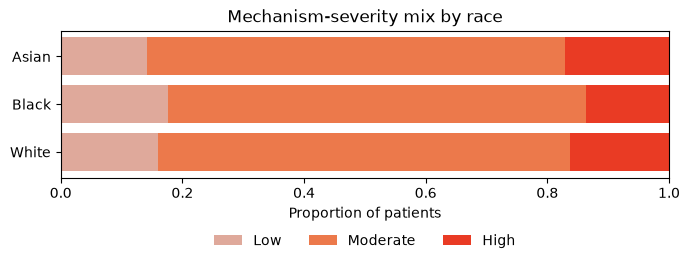

In [14]:
#Stability check figure: mechanism-severity mix by race
import pandas as pd
import matplotlib.pyplot as plt

races_of_interest = ["White", "Black", "Asian"]
severity_order = ["Low", "Moderate", "High"]

severity_mix = pd.crosstab(cleaned["Race"], cleaned["High_impact_InjSev"], normalize="index")
severity_mix = severity_mix.loc[races_of_interest, severity_order]

colors = ["#dfa99b", "#ec794b", "#e93b24"]

fig, ax = plt.subplots(figsize=(7, 3))
left = pd.Series(0, index=races_of_interest)
for level, color in zip(severity_order, colors):
    ax.barh(races_of_interest, severity_mix[level], left=left, color=color, label=level)
    left += severity_mix[level]

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of patients")
ax.set_title("Mechanism-severity mix by race")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR + "/severity_mix_by_race.png", dpi=150)
plt.show()

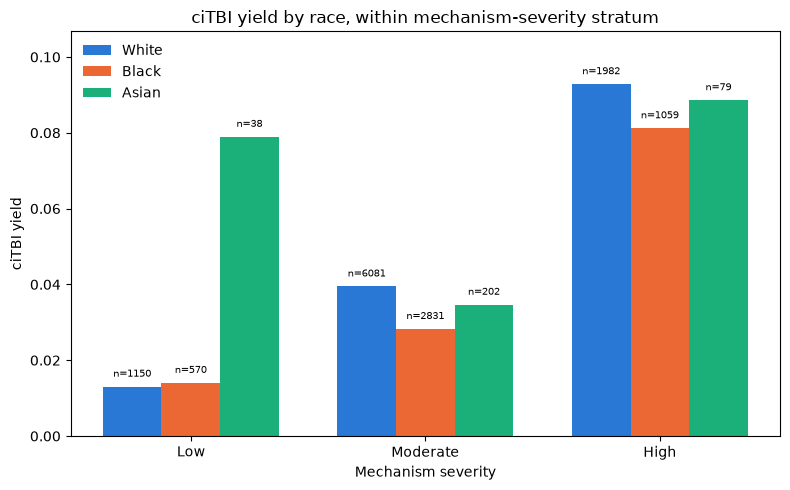

In [15]:
#Stability check figure (after): ciTBI yield by race, within severity stratum
import numpy as np

ct_patients = cleaned[cleaned["CTDone"] == "Yes"].copy()

rows = []
for level in severity_order:
    sub = ct_patients[ct_patients["High_impact_InjSev"] == level]
    for race in races_of_interest:
        race_sub = sub[sub["Race"] == race]
        n = len(race_sub)
        yield_rate = (race_sub["PosIntFinal"] == "Yes").mean() if n > 0 else np.nan
        rows.append({"severity": level, "race": race, "n": n, "yield": yield_rate})

yield_df = pd.DataFrame(rows)

x = np.arange(len(severity_order))
bar_width = 0.25
colors = {"White": "#2a78d6", "Black": "#eb6834", "Asian": "#1baf7a"}

fig, ax = plt.subplots(figsize=(8, 5))
for i, race in enumerate(races_of_interest):
    race_data = yield_df[yield_df["race"] == race].set_index("severity").loc[severity_order]
    offset = (i - 1) * bar_width
    ax.bar(x + offset, race_data["yield"], width=bar_width, color=colors[race], label=race)
    for xi, (n, val) in enumerate(zip(race_data["n"], race_data["yield"])):
        ax.text(x[xi] + offset, val + 0.002, f"n={n}", ha="center", va="bottom", fontsize=7, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(severity_order)
ax.set_xlabel("Mechanism severity")
ax.set_ylabel("ciTBI yield")
ax.set_title("ciTBI yield by race, within mechanism-severity stratum")
ax.legend(frameon=False)
ax.set_ylim(0, yield_df["yield"].max() * 1.15)
plt.tight_layout()
plt.savefig(FIGDIR + "/yield_by_race_and_severity.png", dpi=150)
plt.show()

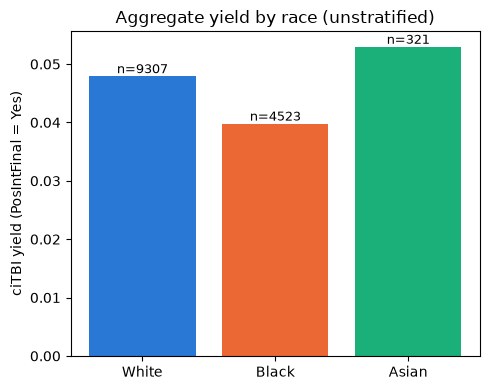

In [16]:
#Stability check figure (before): aggregate ciTBI yield by race among scanned patients, unstratified by severity -- compare against the stratified chart above
import matplotlib.pyplot as plt

race_colors = {"White": "#2a78d6", "Black": "#eb6834", "Asian": "#1baf7a"}
races = ["White", "Black", "Asian"]

ct_patients_before = cleaned[(cleaned["CTDone"] == "Yes") & (cleaned["Race"].isin(races))]
yield_by_race = (
    ct_patients_before
    .groupby("Race")["PosIntFinal"]
    .apply(lambda s: (s == "Yes").mean())
    .reindex(races)
)
n_by_race = ct_patients_before.groupby("Race").size().reindex(races)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(races, yield_by_race.values, color=[race_colors[r] for r in races])

for bar, n in zip(bars, n_by_race):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"n={n}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("ciTBI yield (PosIntFinal = Yes)")
ax.set_title("Aggregate yield by race (unstratified)")
# ax.set_ylim(0, <match the after-chart's ymax here>)
plt.tight_layout()
plt.savefig(FIGDIR + "/before_race_yield.png", dpi=150)
plt.show()

In [15]:
#Reality check: cleaned dataset vs. Kuppermann et al. (2009)
import pandas as pd

paper_stats = {
    "Total N": 42412,
    "CT rate (%)": 35.3,
    "TBI-on-CT rate among scanned (%)": 5.2,
    "ciTBI rate overall (%)": 0.9,
    "Neurosurgery rate among ciTBI (%)": 15.9,
    "Hospital admission rate (%)": 9.0,
}

n_total = len(cleaned)
n_ct = (cleaned["CTDone"] == "Yes").sum()
n_ct_pos = (cleaned.loc[cleaned["CTDone"] == "Yes", "PosCT"] == "Yes").sum()
n_citbi = (cleaned["PosIntFinal"] == "Yes").sum()
n_citbi_neuro = (cleaned.loc[cleaned["PosIntFinal"] == "Yes", "Neurosurgery"] == "Yes").sum()
n_hosphead = (cleaned["HospHead"] == "Yes").sum()

computed_stats = {
    "Total N": n_total,
    "CT rate (%)": 100 * n_ct / n_total,
    "TBI-on-CT rate among scanned (%)": 100 * n_ct_pos / n_ct,
    "ciTBI rate overall (%)": 100 * n_citbi / n_total,
    "Neurosurgery rate among ciTBI (%)": 100 * n_citbi_neuro / n_citbi,
    "Hospital admission rate (%)": 100 * n_hosphead / n_total,  # caveat: HospHead is 2+ nights, narrower than paper's "admitted"
}

comparison = pd.DataFrame({
    "Paper (Kuppermann 2009)": paper_stats,
    "Cleaned dataset": computed_stats,
})
comparison["Abs. difference"] = comparison["Cleaned dataset"] - comparison["Paper (Kuppermann 2009)"]
print(comparison.round(2))



                                   Paper (Kuppermann 2009)  Cleaned dataset  \
Total N                                            42412.0         43399.00   
CT rate (%)                                           35.3            36.63   
TBI-on-CT rate among scanned (%)                       5.2             7.27   
ciTBI rate overall (%)                                 0.9             1.76   
Neurosurgery rate among ciTBI (%)                     15.9            26.21   
Hospital admission rate (%)                            9.0             2.00   

                                   Abs. difference  
Total N                                     987.00  
CT rate (%)                                   1.33  
TBI-on-CT rate among scanned (%)              2.07  
ciTBI rate overall (%)                        0.86  
Neurosurgery rate among ciTBI (%)            10.31  
Hospital admission rate (%)                  -7.00  


In [16]:
#Reality check: verify against the paper's exact analytic cohort (GCS 14-15)
gcs_1415 = cleaned[cleaned["GCSTotal"].isin([14, 15])].dropna(subset=["PosIntFinal"])
print(f"n = {len(gcs_1415)}  (paper: 42412)")

n_total = len(gcs_1415)
n_ct = (gcs_1415["CTDone"] == "Yes").sum()
n_ct_pos = (gcs_1415.loc[gcs_1415["CTDone"] == "Yes", "PosCT"] == "Yes").sum()
n_citbi = (gcs_1415["PosIntFinal"] == "Yes").sum()
n_citbi_neuro = (gcs_1415.loc[gcs_1415["PosIntFinal"] == "Yes", "Neurosurgery"] == "Yes").sum()

print(f"CT rate: {100*n_ct/n_total:.1f}%  (paper: 35.3%)")
print(f"TBI-on-CT rate: {100*n_ct_pos/n_ct:.1f}%  (paper: 5.2%)")
print(f"ciTBI rate: {100*n_citbi/n_total:.2f}%  (paper: 0.9%)")
print(f"Neurosurgery among ciTBI: {100*n_citbi_neuro/n_citbi:.1f}%  (paper: 15.9%)")

comparison_display = comparison.round(2).reset_index().rename(columns={"index": "Metric"})
print(comparison_display.to_latex(index=False, caption="Cleaned dataset vs. Kuppermann et al. (2009)", label="tab:reality-check"))

n = 42412  (paper: 42412)
CT rate: 35.3%  (paper: 35.3%)
TBI-on-CT rate: 5.2%  (paper: 5.2%)
ciTBI rate: 0.89%  (paper: 0.9%)
Neurosurgery among ciTBI: 16.0%  (paper: 15.9%)
\begin{table}
\caption{Cleaned dataset vs. Kuppermann et al. (2009)}
\label{tab:reality-check}
\begin{tabular}{lrrr}
\toprule
Metric & Paper (Kuppermann 2009) & Cleaned dataset & Abs. difference \\
\midrule
Total N & 42412.000000 & 43399.000000 & 987.000000 \\
CT rate (%) & 35.300000 & 36.630000 & 1.330000 \\
TBI-on-CT rate among scanned (%) & 5.200000 & 7.270000 & 2.070000 \\
ciTBI rate overall (%) & 0.900000 & 1.760000 & 0.860000 \\
Neurosurgery rate among ciTBI (%) & 15.900000 & 26.210000 & 10.310000 \\
Hospital admission rate (%) & 9.000000 & 2.000000 & -7.000000 \\
\bottomrule
\end{tabular}
\end{table}



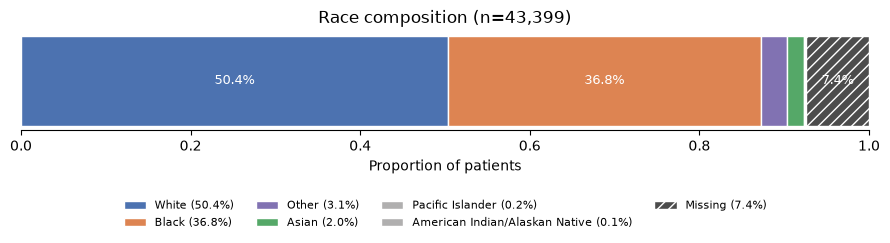

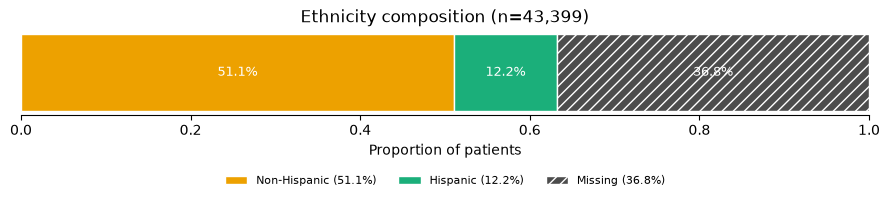

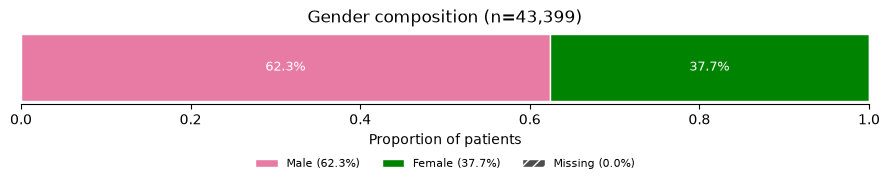

In [17]:
#Demographic composition charts: Race / Ethnicity / Gender
import matplotlib.patches as mpatches

demo_colors = {
    "White": "#4C72B0", "Black": "#DD8452", "Asian": "#55A868",
    "Other": "#8172B2", "American Indian/Alaskan Native": "#B0AFAF",
    "Pacific Islander": "#B0AFAF",
    "Hispanic": "#1baf7a", "Non-Hispanic": "#eda100",
    "Male": "#e87ba4", "Female": "#008300",
}


def plot_stacked_composition(col, filename, figsize=(9, 3)):
    """Plot a horizontal stacked-proportion bar for one demographic column,
    with missingness shown as its own hatched, muted segment."""
    col_data = cleaned[col].fillna("Missing")
    counts = col_data.value_counts()
    order = [c for c in counts.index if c != "Missing"] + (["Missing"] if "Missing" in counts.index else [])
    counts = counts.reindex(order)
    total = counts.sum()
    props = counts / total

    fig, ax = plt.subplots(figsize=figsize)
    left = 0
    legend_handles = []
    for label, prop in props.items():
        color = demo_colors.get(label, "#4C4C4C")
        hatch = "///" if label == "Missing" else None
        ax.barh(0, prop, left=left, color=color, hatch=hatch, edgecolor="white", height=0.6)
        if prop >= 0.06:
            ax.text(left + prop / 2, 0, f"{prop:.1%}", ha="center", va="center",
                    fontsize=9, color="white")
        legend_handles.append(mpatches.Patch(facecolor=color, hatch=hatch, edgecolor="white",
                                              label=f"{label} ({prop:.1%})"))
        left += prop

    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Proportion of patients")
    ax.set_title(f"{col} composition (n={total:,})")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.6),
              ncol=min(len(legend_handles), 4), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR + "/" + filename, dpi=400, bbox_inches="tight")
    plt.show()


plot_stacked_composition("Race", "race_composition.png", figsize=(9, 3.6))
plot_stacked_composition("Ethnicity", "ethnicity_composition.png", figsize=(9, 3))
plot_stacked_composition("Gender", "gender_composition.png", figsize=(9, 2.8))


In [8]:
#Modelling: predicting ciTBI (PosIntFinal) from pre-CT variables
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

features = ["LOCSeparate", "AMS", "Vomit", "HA_verb"]  

X_raw = cleaned[features].dropna()
X = pd.get_dummies(X_raw, drop_first=True)   
y = cleaned.loc[X.index, "PosIntFinal"] == "Yes"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

#Model 1
m1 = LogisticRegression(max_iter=1000)
m1.fit(X_train, y_train)
print("LogReg AUC:", roc_auc_score(y_test, m1.predict_proba(X_test)[:, 1]))

#Model 2
m2 = DecisionTreeClassifier(max_depth=4, random_state=0)  # TODO: justify this choice / depth
m2.fit(X_train, y_train)
print("Tree AUC:", roc_auc_score(y_test, m2.predict_proba(X_test)[:, 1]))

LogReg AUC: 0.8761011011011011
Tree AUC: 0.8642946224913439


In [9]:
print(pd.Series(m1.coef_[0], index=X.columns).sort_values())

HA_verb_Yes                      0.508022
Vomit_Yes                        0.695496
HA_verb_Pre-verbal/Non-verbal    1.495543
LOCSeparate_Suspected            1.655292
LOCSeparate_Yes                  1.964866
AMS_Yes                          2.239751
dtype: float64


In [10]:
print(pd.Series(m2.feature_importances_, index=X.columns).sort_values())

HA_verb_Yes                      0.003020
LOCSeparate_Suspected            0.037754
Vomit_Yes                        0.050658
LOCSeparate_Yes                  0.198536
AMS_Yes                          0.304544
HA_verb_Pre-verbal/Non-verbal    0.405488
dtype: float64


LogReg AUC (severity-controlled): 0.9144944489166162
Tree   AUC (severity-controlled): 0.8968123197155699

Logistic coefficients (severity-controlled):
High_impact_InjSev_Low          -2.153066
High_impact_InjSev_Moderate     -1.024891
HA_verb_Yes                      0.567950
Vomit_Yes                        0.828868
HA_verb_Pre-verbal/Non-verbal    1.358317
LOCSeparate_Suspected            1.484850
LOCSeparate_Yes                  1.906533
AMS_Yes                          2.021765
dtype: float64

Tree feature importances (severity-controlled):
High_impact_InjSev_Moderate      0.000360
HA_verb_Yes                      0.004901
LOCSeparate_Suspected            0.035793
Vomit_Yes                        0.057746
High_impact_InjSev_Low           0.072409
LOCSeparate_Yes                  0.182069
AMS_Yes                          0.271637
HA_verb_Pre-verbal/Non-verbal    0.375085
dtype: float64


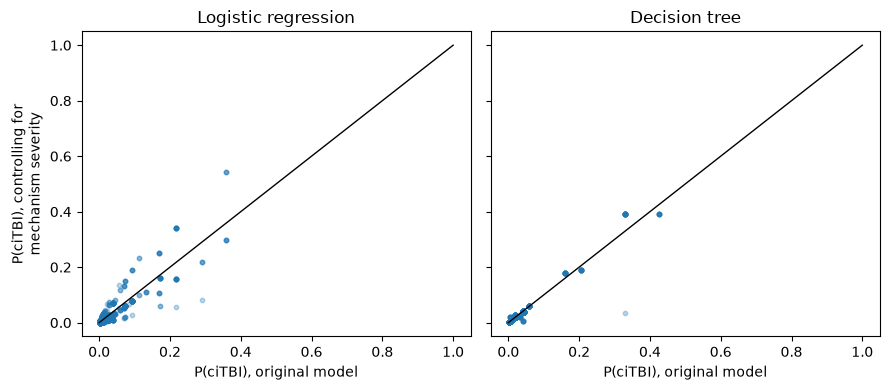

In [ ]:
#stability check
sev_col = "High_impact_InjSev" 

#refit both models with mechanism severity added as a control
features_ctrl = features + [sev_col]
X_raw_ctrl = cleaned[features_ctrl].dropna()
X_ctrl = pd.get_dummies(X_raw_ctrl, drop_first=True)
y_ctrl = cleaned.loc[X_ctrl.index, "PosIntFinal"] == "Yes"

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_ctrl, y_ctrl, test_size=0.25, random_state=0, stratify=y_ctrl
)

m1_ctrl = LogisticRegression(max_iter=1000).fit(X_train_c, y_train_c)
m2_ctrl = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train_c, y_train_c)

print("LogReg AUC (severity-controlled):", roc_auc_score(y_test_c, m1_ctrl.predict_proba(X_test_c)[:, 1]))
print("Tree   AUC (severity-controlled):", roc_auc_score(y_test_c, m2_ctrl.predict_proba(X_test_c)[:, 1]))

print("\nLogistic coefficients (severity-controlled):")
print(pd.Series(m1_ctrl.coef_[0], index=X_ctrl.columns).sort_values())

print("\nTree feature importances (severity-controlled):")
print(pd.Series(m2_ctrl.feature_importances_, index=X_ctrl.columns).sort_values())

# ---- Figure for Section 4.2: predicted prob. before vs after control ----
# restrict to test rows common to both splits (dropna on sev_col may have
# dropped a few extra rows relative to the original X_test)
common_idx = X_test.index.intersection(X_test_c.index)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, m, m_ctrl, name in zip(
    axes, [m1, m2], [m1_ctrl, m2_ctrl], ["Logistic regression", "Decision tree"]
):
    p_before = pd.Series(m.predict_proba(X_test)[:, 1], index=X_test.index).loc[common_idx]
    p_after = pd.Series(m_ctrl.predict_proba(X_test_c)[:, 1], index=X_test_c.index).loc[common_idx]
    ax.scatter(p_before, p_after, alpha=0.3, s=10)
    ax.plot([0, 1], [0, 1], color="black", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("P(ciTBI), original model")
axes[0].set_ylabel("P(ciTBI), controlling for\nmechanism severity")
plt.tight_layout()
plt.savefig(FIGDIR + "/stability_severity_control.png", dpi=200)
plt.show()
